# 🚗 Car Price Prediction

Car price prediction is a common real-world problem in the automotive industry, where the value of a vehicle depends on multiple factors such as age, fuel type, usage, and transmission.

The objective of this project is to build a regression model that can accurately estimate the selling price of a used car based on its features.

This model can help:
- Sellers set competitive prices  
- Buyers evaluate fair market value  
- Businesses optimize pricing strategies  




## Importing Libraries

We import the required libraries for data manipulation, visualization, and machine learning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

The dataset contains information about used cars, including their features and selling prices.

In [4]:
df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Initial Data Exploration

We examine the structure, data types, and statistical summary of the dataset.

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


## Data Cleaning

We clean the dataset by removing unnecessary columns and preparing it for analysis.

In [6]:
# Drop Car_Name (not useful for prediction)
df.drop(['Car_Name'], axis=1, inplace=True)

## Feature Engineering

We create a new feature 'Car_Age' from the 'Year' column to better represent the data.

In [7]:
df['Car_Age'] = 2024 - df['Year']
df.drop(['Year'], axis=1, inplace=True)

## Exploratory Data Analysis (EDA)

We analyze relationships between features and the selling price.

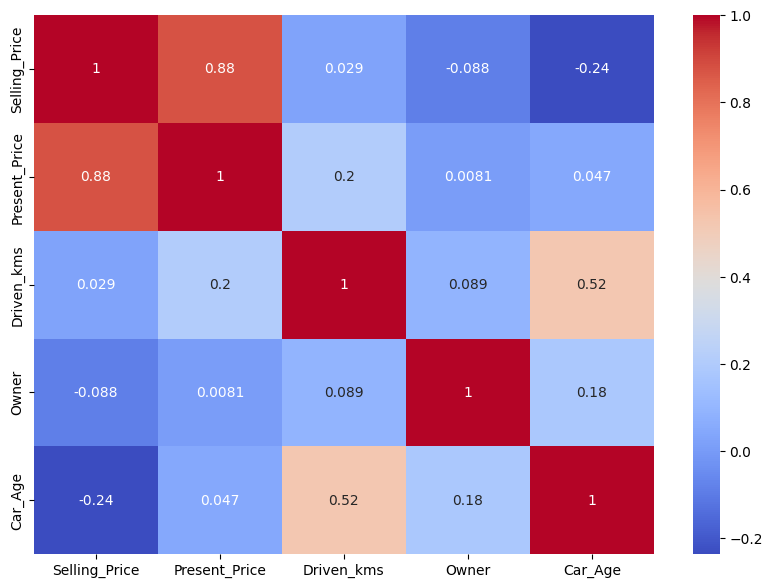

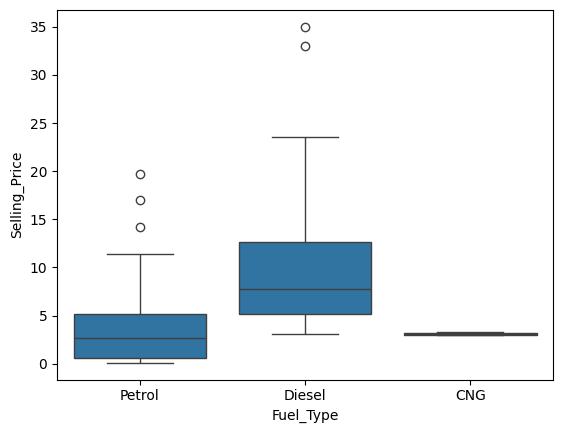

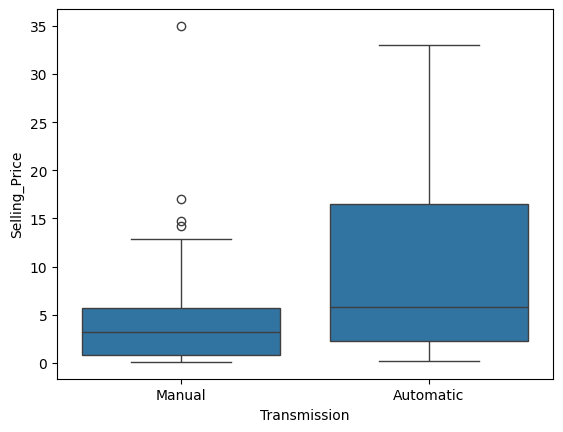

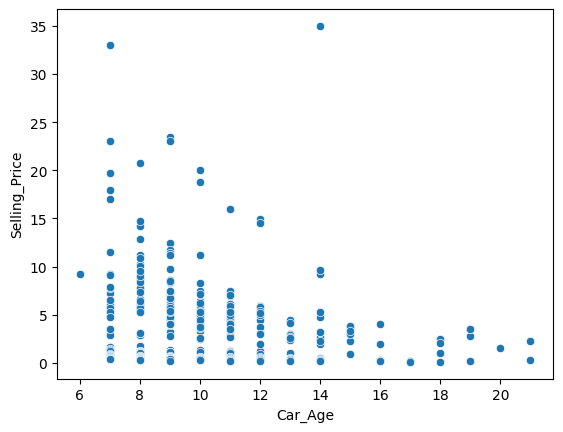

In [8]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Fuel type vs price
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.show()

# Transmission vs price
sns.boxplot(x='Transmission', y='Selling_Price', data=df)
plt.show()

# Car age vs price
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)
plt.show()

## EDA Insight

- Selling price shows a strong positive relationship with present price, indicating that current market value heavily influences resale value  
- Car age has a clear negative relationship with selling price, reflecting depreciation over time  
- Fuel type and transmission introduce noticeable variation in pricing, suggesting their impact on buyer preference  
- The dataset appears clean with no major missing values, making it suitable for modeling without heavy preprocessing

The strong correlation between present price and selling price indicates that current market value is the primary driver of resale pricing.

## Encoding Categorical Variables

Categorical variables are converted into numerical format using one-hot encoding.

In [9]:
df = pd.get_dummies(df, drop_first=True)

#Convert boolean to int
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,0,1,0,1
1,4.75,9.54,43000,0,11,1,0,0,1
2,7.25,9.85,6900,0,7,0,1,0,1
3,2.85,4.15,5200,0,13,0,1,0,1
4,4.60,6.87,42450,0,10,1,0,0,1


## Model Building

To evaluate different approaches, three regression models are used:

- Linear Regression: A baseline model that assumes a linear relationship between features and price  
- Decision Tree Regressor: Captures non-linear patterns in the data  
- Random Forest Regressor: An ensemble model that improves accuracy and reduces overfitting  

Using multiple models allows comparison and helps identify the most reliable approach.

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training
we are training our model in 3 different algorithms.


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)

## Model Evaluation

Model performance is evaluated using:

- Mean Absolute Error (MAE): Measures average prediction error  
- Mean Squared Error (MSE): Penalizes larger errors more heavily  
- R² Score: Indicates how well the model explains variance in the data  

These metrics help evaluate both prediction accuracy and model reliability across different error perspectives.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))


Linear Regression
MAE: 1.2163740193330348
MSE: 3.481349830511816
R2: 0.8488707839193155

Decision Tree
MAE: 0.6924590163934425
MSE: 1.1031475409836065
R2: 0.9521111548086861

Random Forest
MAE: 0.6475360655737711
MSE: 1.0391971090163938
R2: 0.9548873132304915


## Model Comparison

- Linear Regression provides a baseline but is limited to linear relationships  
- Decision Tree captures complex patterns but may overfit  
- Random Forest achieves the best performance due to its ensemble nature and ability to generalize well  

Based on evaluation metrics, Random Forest is selected as the most reliable model for this task.

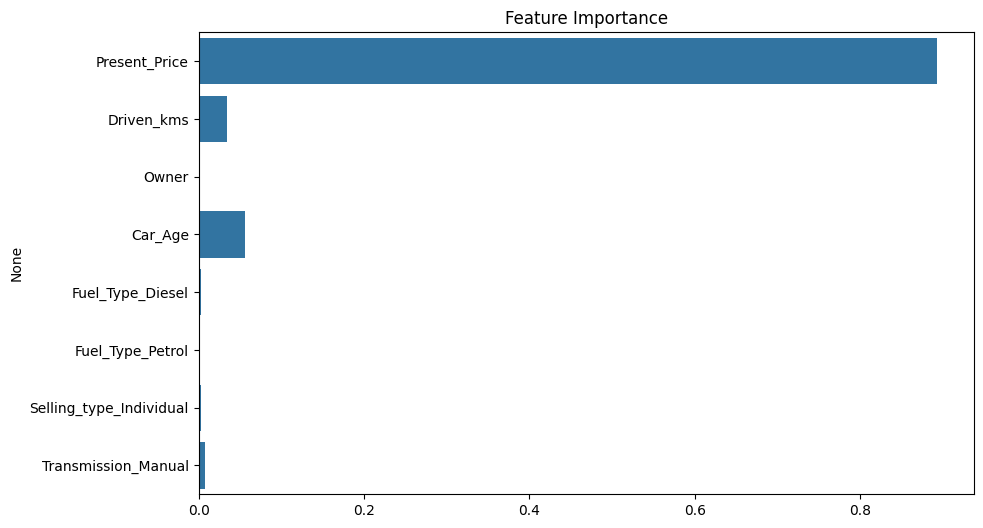

In [13]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

## Feature Importance Insights

- Present price is the dominant factor influencing selling price  
- Car age plays a significant role in depreciation  
- Other features such as fuel type and transmission contribute additional predictive value  

This confirms that both market value and usage-related factors drive car pricing.

## Conclusion

This project demonstrates a complete machine learning workflow for predicting car prices using real-world features.

Key findings:
- Present price and car age are the most influential factors  
- Ensemble models like Random Forest outperform simpler models  
- Proper feature engineering and evaluation improve model reliability  

Although the dataset is clean and relatively simple, real-world datasets may require more advanced preprocessing and tuning.

Overall, this project highlights how data-driven approaches can support better pricing decisions in the automotive market.

The dataset is relatively small and well-structured, which makes prediction easier compared to real-world scenarios.